In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import math
import numpy as np 
import pandas as pd 
import os
import zipfile


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

os.makedirs("/kaggle/working/img/", exist_ok=True)


Checking pair: (105, 600) and (980, 810), distance: 899.847
Checking pair: (105, 600) and (600, 570), distance: 495.908
Checking pair: (105, 600) and (580, 860), distance: 541.503
Checking pair: (105, 600) and (210, 780), distance: 208.387
Checking pair: (105, 600) and (510, 230), distance: 548.566
Checking pair: (105, 600) and (420, 570), distance: 316.425
Checking pair: (105, 600) and (890, 40), distance: 964.274
Checking pair: (105, 600) and (202, 140), distance: 470.116
Checking pair: (105, 600) and (240, 20), distance: 595.504
Checking pair: (980, 810) and (600, 570), distance: 449.444
Checking pair: (980, 810) and (580, 860), distance: 403.113
Checking pair: (980, 810) and (210, 780), distance: 770.584
Checking pair: (980, 810) and (510, 230), distance: 746.525
Checking pair: (980, 810) and (420, 570), distance: 609.262
Checking pair: (980, 810) and (890, 40), distance: 775.242
Checking pair: (980, 810) and (202, 140), distance: 1026.735
Checking pair: (980, 810) and (240, 20), d

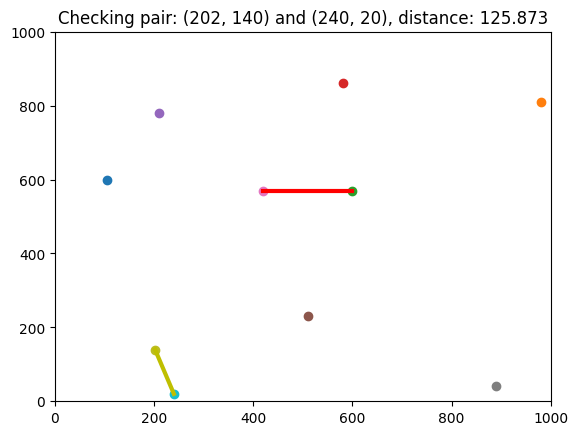

In [2]:
import math
import matplotlib.pyplot as plt
import os

MAX_POINTS = 10
MAX_COORD = 1000
INFINITY = float('inf')
num_points = MAX_POINTS

class Point:
    def __init__(self, x=0, y=0, id=0):
        self.x = x
        self.y = y
        self.id = id

point_coords = [
    (105, 600), (980, 810), (600, 570), (580, 860), (210, 780),
    (510, 230), (420, 570), (890, 40), (202, 140), (240, 20)
]

points = [Point(x=coord[0], y=coord[1], id=i) for i, coord in enumerate(point_coords)]
min_dist = INFINITY
closest_pair_indices = (-1, -1)
closest_pair_points = [Point(), Point()]

def initialize():
    global min_dist
    min_dist = INFINITY

def calculate_distance(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)

def update_closest_pair(p1, p2):
    global min_dist, closest_pair_indices, closest_pair_points
    dist = calculate_distance(p1, p2)
    if dist < min_dist:
        min_dist = dist
        closest_pair_indices = (p1.id, p2.id)
        closest_pair_points[0] = p1
        closest_pair_points[1] = p2
    print_closest_pair_info()

def print_closest_pair_info():
    p1, p2 = closest_pair_points
    print("Closest pair info:")
    print(f"p1: ({p1.x}, {p1.y})")
    print(f"p2: ({p2.x}, {p2.y})")
    print(f"mindist: {min_dist}")

# ----------------- Visualization ----------------- #
img_counter = 0
img_folder = 'img'
os.makedirs(img_folder, exist_ok=True)

def show_plot(p1, p2, dist):
    global MAX_COORD, img_counter
    plt.clf()
    plt.xlim(0, MAX_COORD)
    plt.ylim(0, MAX_COORD)
    for point in points:
        plt.scatter(point.x, point.y)
    plt.plot([p1.x, p2.x], [p1.y, p2.y], c="y", lw=3)
    if closest_pair_indices[0] != -1:
        plt.plot([closest_pair_points[0].x, closest_pair_points[1].x], 
                 [closest_pair_points[0].y, closest_pair_points[1].y], 
                 c="r", lw=3)
    plt.title(f"Checking pair: ({p1.x}, {p1.y}) and ({p2.x}, {p2.y}), distance: {dist:.3f}")
    img_counter += 1
    plt.savefig(f"{img_folder}/closest_pair_{img_counter}.png")

# ----------------- Brute Force ----------------- #
def find_closest_pair_bruteforce():
    global min_dist, closest_pair_indices, closest_pair_points
    for i in range(num_points):
        for j in range(i + 1, num_points):
            p1 = points[i]
            p2 = points[j]
            dist = calculate_distance(p1, p2)
            show_plot(p1, p2, dist)
            if dist < min_dist:
                min_dist = dist
                closest_pair_indices = (p1.id, p2.id)
                closest_pair_points[0] = p1
                closest_pair_points[1] = p2
            print(f"Checking pair: ({p1.x}, {p1.y}) and ({p2.x}, {p2.y}), distance: {dist:.3f}")
    print_closest_pair_info()

# ----------------- Results ----------------- #
def print_results():
    points.sort(key=lambda p: p.id)
    print(f"p1: ({closest_pair_points[0].x}, {closest_pair_points[0].y}), id: {closest_pair_points[0].id}")
    print(f"p2: ({closest_pair_points[1].x}, {closest_pair_points[1].y}), id: {closest_pair_points[1].id}")
    print(f"mindist: {min_dist:.3f}")

# ----------------- Main Program ----------------- #

initialize()
find_closest_pair_bruteforce()
print_results()

In [3]:
#“打包图片”#
# 指定要打包的文件夹路径
folder_to_zip = '/kaggle/working/img/'

# 指定要创建的zip文件路径
zip_file_path = '/kaggle/working/images.zip'

# 创建一个zip文件对象
with zipfile.ZipFile(zip_file_path, 'w') as zipf:
    # 遍历文件夹中的所有文件，并将它们添加到zip文件中
    for root, dirs, files in os.walk(folder_to_zip):
        for file in files:
            file_path = os.path.join(root, file)
            # 将文件添加到zip文件中
            zipf.write(file_path, os.path.relpath(file_path, folder_to_zip))

print(f'成功创建zip文件：{zip_file_path}')

成功创建zip文件：/kaggle/working/images.zip


In [4]:
!pip install opencv-python


In [5]:
import cv2
import os

# 图像所在的文件夹路径
img_folder = '/kaggle/working/img'  # 确保图像文件上传到此目录
output_video = '/kaggle/working/output_video.avi'  # 输出的视频路径

# 设置视频的帧率
fps = 2  # 可根据需求调整

# 获取文件夹内所有图像文件，并按顺序排序
img_files = [f for f in os.listdir(img_folder) if f.endswith('.png')]
img_files.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))  # 按文件名中的数字部分排序

# 读取第一张图像来获取尺寸
first_img = cv2.imread(os.path.join(img_folder, img_files[0]))
height, width, _ = first_img.shape

# 定义视频的编码方式及输出视频
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # 使用 XVID 编码
video_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# 遍历图像文件并将其写入视频
for img_file in img_files:
    img_path = os.path.join(img_folder, img_file)
    img = cv2.imread(img_path)
    video_writer.write(img)  # 将图像写入视频

# 释放资源
video_writer.release()
print(f"视频已保存为 {output_video}")

视频已保存为 /kaggle/working/output_video.avi
